### ML baseline points
1. Load the same split dataset prepared
2. Read YOLO annotation files  
3. Crop weed instances from bounding boxes  
4. Extract handcrafted features from each crop:
   - HOG
   - Color histogram
5. Train classical classifiers:
   - SVM
   - Random Forest
6. Evaluate with:
   - Accuracy
   - Precision / Recall / F1
   - Confusion matrix


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.svm import SVC
from collections import Counter
from skimage.feature import hog
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [ ]:
# Use the dataset already prepared
DATASET_PATH = Path("./dataset")

IMAGES_DIR = DATASET_PATH / "images"
LABELS_DIR = DATASET_PATH / "labels"

SPLITS = ["train", "val", "test"]

# Weed classes
ALLOWED_CLASSES = [0, 1, 2, 3, 4, 5]

# Crop/feature parameters
CROP_SIZE = (64, 64)
HIST_BINS = 16
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

RANDOM_STATE = 42


In [ ]:
# Basic dataset checks
for split in SPLITS:
    print(f"Split: {split}")
    print(" Images folder exists:", (IMAGES_DIR / split).exists())
    print(" Labels folder exists:", (LABELS_DIR / split).exists())
    print("-" * 40)


Split: train
 Images folder exists: True
 Labels folder exists: True
----------------------------------------
Split: val
 Images folder exists: True
 Labels folder exists: True
----------------------------------------
Split: test
 Images folder exists: True
 Labels folder exists: True
----------------------------------------


In [ ]:
# Helper functions

def yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h):
    """Convert YOLO normalized bounding box to pixel coordinates"""
    x1 = int((xc - bw / 2) * img_w)
    y1 = int((yc - bh / 2) * img_h)
    x2 = int((xc + bw / 2) * img_w)
    y2 = int((yc + bh / 2) * img_h)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return x1, y1, x2, y2


def extract_color_histogram(image_rgb, bins=16):
    """Extract normalized RGB color histogram"""
    features = []
    for ch in range(3):
        hist = cv2.calcHist([image_rgb], [ch], None, [bins], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-8)
        features.extend(hist)
    return np.array(features, dtype=np.float32)


def extract_hog_features(image_rgb):
    """Extract HOG features from grayscale crop"""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )
    return np.array(features, dtype=np.float32)


def extract_features(image_rgb):
    """Combine HOG + color histogram"""
    hog_feat = extract_hog_features(image_rgb)
    hist_feat = extract_color_histogram(image_rgb, bins=HIST_BINS)
    return np.concatenate([hog_feat, hist_feat]).astype(np.float32)


def read_yolo_annotations(label_path):
    """Read YOLO annotations from a txt file"""
    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) != 5:
            continue

        cls_id, xc, yc, bw, bh = map(float, parts)
        cls_id = int(cls_id)
        boxes.append((cls_id, xc, yc, bw, bh))

    return boxes


In [ ]:
# Build the crop-level dataset
def build_split_dataset(split, allowed_classes=None, crop_size=(64, 64), verbose=True):
    X, y = [], []
    crop_examples = []

    image_paths = sorted(list((IMAGES_DIR / split).glob("*.jpg")) + list((IMAGES_DIR / split).glob("*.JPG")))

    total_images = 0
    total_boxes = 0
    skipped_boxes = 0

    for img_path in image_paths:
        total_images += 1
        label_path = LABELS_DIR / split / f"{img_path.stem}.txt"

        image_bgr = cv2.imread(str(img_path))
        if image_bgr is None:
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]

        boxes = read_yolo_annotations(label_path)
        total_boxes += len(boxes)

        for cls_id, xc, yc, bw, bh in boxes:
            if allowed_classes is not None and cls_id not in allowed_classes:
                continue

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, w, h)

            if x2 <= x1 or y2 <= y1:
                skipped_boxes += 1
                continue

            crop = image_rgb[y1:y2, x1:x2]
            if crop.size == 0:
                skipped_boxes += 1
                continue

            crop = cv2.resize(crop, crop_size)
            features = extract_features(crop)

            X.append(features)
            y.append(cls_id)

            if len(crop_examples) < 8:
                crop_examples.append((crop, cls_id))

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    if verbose:
        print(f"Split: {split}")
        print(f" Total source images: {total_images}")
        print(f" Total YOLO boxes read: {total_boxes}")
        print(f" Total valid crops kept: {len(y)}")
        print(f" Skipped invalid crops: {skipped_boxes}")
        print(f" Class distribution: {dict(sorted(Counter(y).items()))}")
        print("-" * 50)

    return X, y, crop_examples


In [ ]:
# Build the crop-level datasets
X_train, y_train, train_examples = build_split_dataset("train", allowed_classes=ALLOWED_CLASSES, crop_size=CROP_SIZE)
X_val, y_val, val_examples = build_split_dataset("val", allowed_classes=ALLOWED_CLASSES, crop_size=CROP_SIZE)
X_test, y_test, test_examples = build_split_dataset("test", allowed_classes=ALLOWED_CLASSES, crop_size=CROP_SIZE)

print("Feature matrix shapes:")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)


Split: train
 Total source images: 1576
 Total YOLO boxes read: 72316
 Total valid crops kept: 72270
 Skipped invalid crops: 28
 Class distribution: {np.int32(0): 45062, np.int32(1): 5592, np.int32(2): 20562, np.int32(3): 424, np.int32(4): 454, np.int32(5): 176}
--------------------------------------------------
Split: val
 Total source images: 338
 Total YOLO boxes read: 13668
 Total valid crops kept: 13652
 Skipped invalid crops: 10
 Class distribution: {np.int32(0): 8356, np.int32(1): 1510, np.int32(2): 3570, np.int32(3): 112, np.int32(4): 58, np.int32(5): 46}
--------------------------------------------------
Split: test
 Total source images: 340
 Total YOLO boxes read: 14726
 Total valid crops kept: 14704
 Skipped invalid crops: 4
 Class distribution: {np.int32(0): 9754, np.int32(1): 1104, np.int32(2): 3672, np.int32(3): 116, np.int32(4): 36, np.int32(5): 22}
--------------------------------------------------
Feature matrix shapes:
X_train: (72270, 1812)  y_train: (72270,)
X_val: 

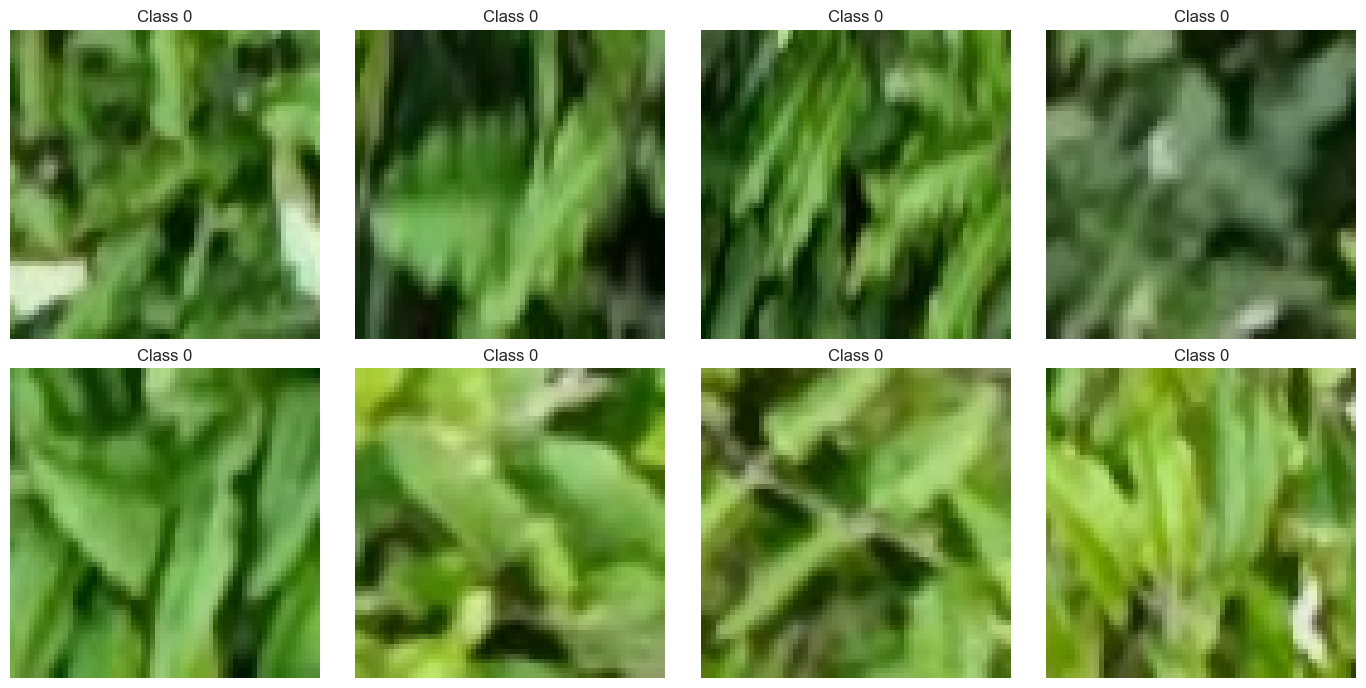

In [ ]:
# Visualize sample weed crops
examples = train_examples if len(train_examples) > 0 else val_examples

if len(examples) == 0:
    print("No crop examples available")
else:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax, (crop, cls_id) in zip(axes, examples):
        ax.imshow(crop)
        ax.set_title(f"Class {cls_id}")
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


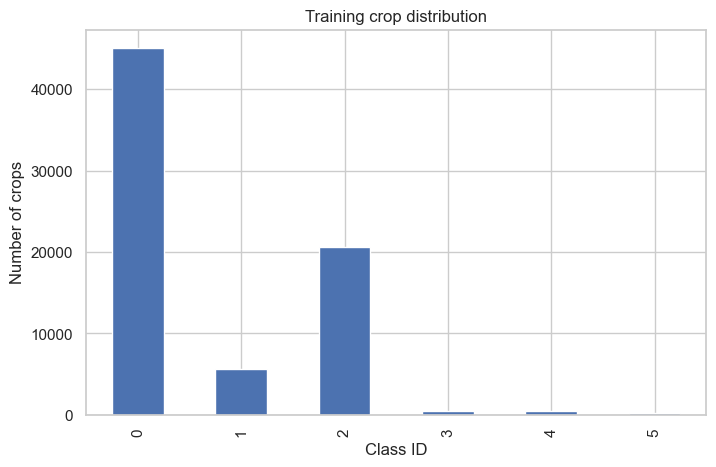

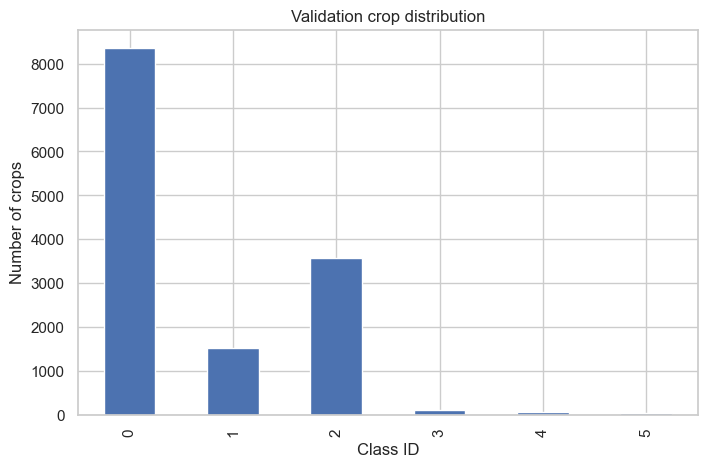

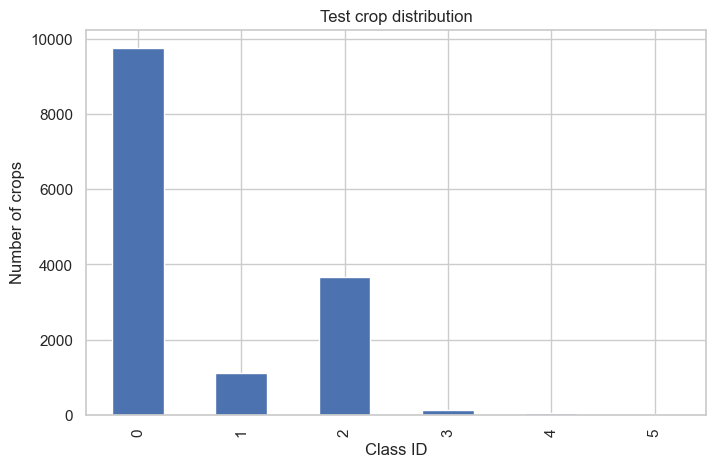

In [ ]:
# Class distribution
def plot_class_distribution(y, title):
    counts = pd.Series(y).value_counts().sort_index()
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("Class ID")
    ax.set_ylabel("Number of crops")
    plt.show()

plot_class_distribution(y_train, "Training crop distribution")
plot_class_distribution(y_val, "Validation crop distribution")
plot_class_distribution(y_test, "Test crop distribution")


In [ ]:
# Training helpers
def evaluate_model(model, X, y, split_name="Validation"):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"{split_name} Accuracy : {acc:.4f}")
    print(f"{split_name} Precision: {precision:.4f}")
    print(f"{split_name} Recall   : {recall:.4f}")
    print(f"{split_name} F1-score : {f1:.4f}")
    print()

    print(f"{split_name} Classification Report")
    print(classification_report(y, y_pred, zero_division=0))

    labels = sorted(np.unique(np.concatenate([y, y_pred])))
    cm = confusion_matrix(y, y_pred, labels=labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }


SVM — Validation Performance
Validation Accuracy : 0.7284
Validation Precision: 0.7090
Validation Recall   : 0.7284
Validation F1-score : 0.7129

Validation Classification Report
              precision    recall  f1-score   support

           0       0.77      0.85      0.81      8356
           1       0.56      0.31      0.40      1510
           2       0.67      0.66      0.66      3570
           3       0.00      0.00      0.00       112
           4       0.00      0.00      0.00        58
           5       1.00      0.43      0.61        46

    accuracy                           0.73     13652
   macro avg       0.50      0.38      0.41     13652
weighted avg       0.71      0.73      0.71     13652



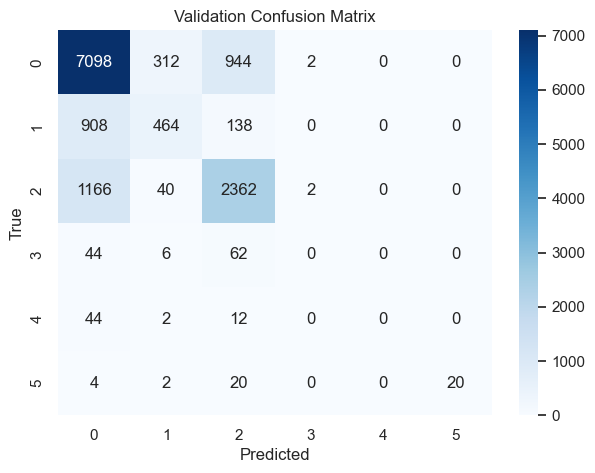

In [10]:
# Train baseline model 1 with SVM
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_model.fit(X_train, y_train)

print("SVM  Validation Performance")
svm_val_metrics = evaluate_model(svm_model, X_val, y_val, split_name="Validation")


Random Forest Validation Performance
Validation Accuracy : 0.6730
Validation Precision: 0.6581
Validation Recall   : 0.6730
Validation F1-score : 0.6006

Validation Classification Report
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      8356
           1       0.48      0.05      0.10      1510
           2       0.73      0.27      0.39      3570
           3       0.00      0.00      0.00       112
           4       0.00      0.00      0.00        58
           5       1.00      0.39      0.56        46

    accuracy                           0.67     13652
   macro avg       0.48      0.28      0.31     13652
weighted avg       0.66      0.67      0.60     13652



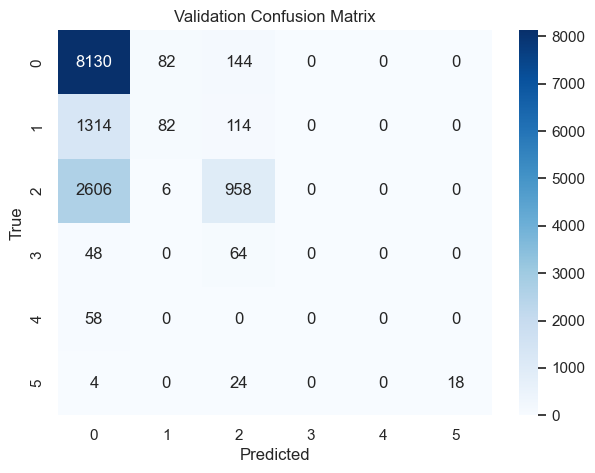

In [11]:
# Train baseline model 2 with Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Validation Performance")
rf_val_metrics = evaluate_model(rf_model, X_val, y_val, split_name="Validation")


In [12]:
# Compare validation results
val_results = pd.DataFrame([
    {"Model": "SVM", **svm_val_metrics},
    {"Model": "Random Forest", **rf_val_metrics}
])

val_results


,Model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,SVM,0.728391,0.709046,0.728391,0.712906
1,Random Forest,0.673015,0.658057,0.673015,0.600589


In [13]:
# Select the best model by weighted F1 on the validation set
best_model_name = val_results.sort_values("f1_weighted", ascending=False).iloc[0]["Model"]
best_model = svm_model if best_model_name == "SVM" else rf_model

print("Best validation model:", best_model_name)


Best validation model: SVM


SVM — Test Performance
Test Accuracy : 0.7588
Test Precision: 0.7479
Test Recall   : 0.7588
Test F1-score : 0.7506

Test Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      9754
           1       0.42      0.31      0.35      1104
           2       0.67      0.70      0.69      3672
           3       0.50      0.02      0.03       116
           4       0.00      0.00      0.00        36
           5       1.00      0.45      0.62        22

    accuracy                           0.76     14704
   macro avg       0.57      0.39      0.42     14704
weighted avg       0.75      0.76      0.75     14704



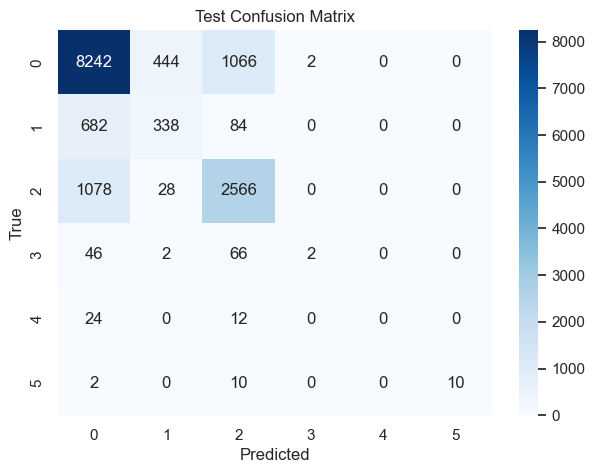

In [14]:
# Final test evaluation
print(f"{best_model_name} — Test Performance")
test_metrics = evaluate_model(best_model, X_test, y_test, split_name="Test")


In [15]:
# Summary table
summary_df = pd.DataFrame([
    {"Model": best_model_name, "Split": "Test", **test_metrics}
])

summary_df


,Model,Split,accuracy,precision_weighted,recall_weighted,f1_weighted
0,SVM,Test,0.758841,0.747871,0.758841,0.750599
